# Fast interactive check: does the probe actually see affinity signal?

Purpose: the batch job (`prob/cluster/run_prob.sub` -> `prob_orchestrate.main`) runs
`GridSearchCV` over prob models, for 3 layers, for the real target plus a possibly shuffled-ident
baseline. That's the right thing for a final number, but it's slow to iterate on and it
hides exactly the kind of bug that causes "predicts the mean": a shape mismatch between
`ids.pt` and `layer_N.pt`, a stale cached tensor, a target file with sentinel/NaN values,
etc. All of those fail *silently* inside a multi-hour condor job and just show up as R2 ~ 0.

This notebook only touches the small cached tensors (`ids.pt`, `layer_N.pt`,
`targets/*.pt`) — never the raw SDF / `KinodataDocked` dataset, which is what actually
takes a long time and a lot of memory to load. 

Workflow:
1. Shape/staleness check for `ids.pt` vs every `layer_N.pt` (catches mismatched/stale files).
2. Quick alpha-sweep Ridge fit (single split, no CV) for the target you care about, vs a
   dummy-mean baseline, vs a known-good reference target on the *same* embeddings — this
   tells you whether the embeddings/pipeline are fine and the target is the problem, or
   vice versa.
3. Layer-wise sweep so you can see where (if anywhere) the signal shows up.
4. Only once a layer/target combo looks promising: an opt-in cell that runs the *real*
   `run_probes`/`linear_models` (GridSearchCV, stats, artifacts) for that one layer, so you
   get an official result without resubmitting the full 3-layer/2-target condor job.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.dummy import DummyRegressor

from prob.paths_and_io import load_out_tensor, load_X_from_pt, load_y_by_ids
from prob.prob_config import get_ds_load_config
from prob.prob_plots import plot_parity, plot_residuals 

RANDOM_STATE = 96
ALPHAS = np.logspace(-5, 4, 10)  # same grid as LINEAR_PROBES ridge in prob_models.py


In [2]:
prob_config = get_ds_load_config()
output_dir = Path(prob_config["output_dir"])
target_dir = Path(prob_config["target_dir"])
print(f"output_dir: {output_dir}")
print(f"target_dir: {target_dir}")

# What to probe. Change these and re-run from here down.
TARGET_FILE = "affinity.pt"
REFERENCE_TARGET_FILE = "nitrogen_counts.pt"  # cheap sanity check: this should always decode well
LAYERS = [1, 2, 3]


output_dir: /home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/CGNN-3D/rmsd_cutoff_2/random-k-fold
target_dir: /home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/targets


# 0. Check the original model's results

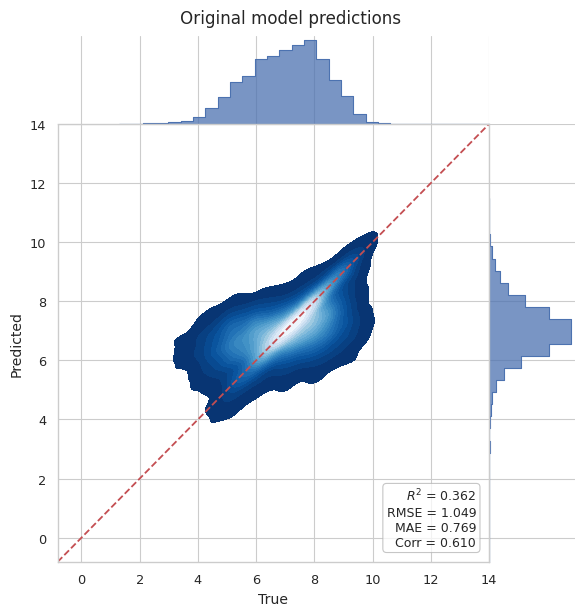

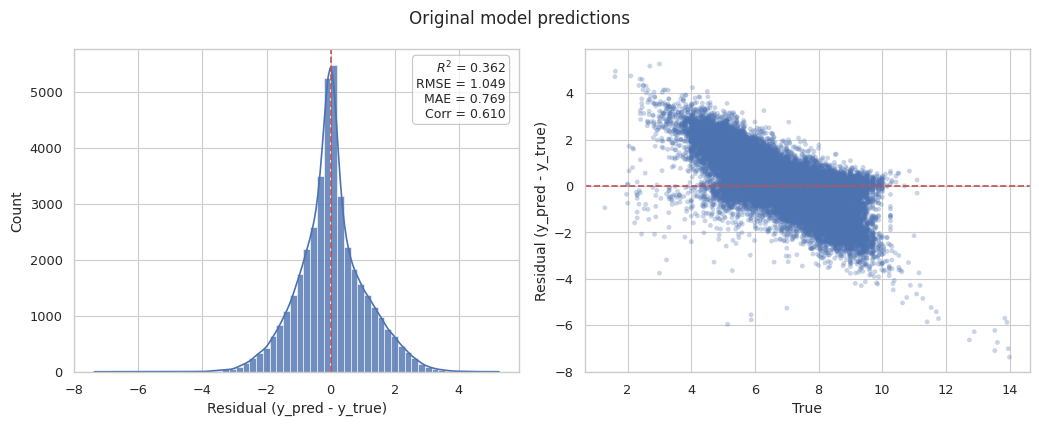

In [ ]:
org_preds = pd.read_csv(output_dir / "predictions.csv")

plot_parity(org_preds["y_true"], org_preds["y_pred"], title="Original Model Predictions",
            density="kde",
            save_path=output_dir / "parity_original_model.png")

plot_residuals(org_preds["y_true"], org_preds["y_pred"], title="Original Model Predictions",
               vs_true=True,
               save_path=output_dir / "residuals_original_model.png")


## 1. Shape / staleness check

`load_X_from_pt` and `load_y_by_ids` both silently trust whatever tensor is on disk.
If `layer_N.pt` was regenerated but `ids.pt` wasn't (or vice versa), or if a stale
smoke-test tensor got left behind at the top-level output dir, you get a length
mismatch or, worse, embeddings and ids that both "look" fine in isolation but no
longer correspond row-for-row. Check this first, every time, before trusting any R2.

In [5]:
ids = load_out_tensor(output_dir, "ids.pt").cpu().numpy().astype(int)
print(f"ids.pt: {ids.shape[0]} rows, {len(set(ids.tolist()))} unique idents")

layer_shapes = {}
for layer in LAYERS:
    fp = output_dir / f"layer_{layer}.pt"
    mtime = pd.Timestamp(fp.stat().st_mtime, unit="s") if fp.exists() else None
    X = load_X_from_pt(output_dir, layer_num=layer)
    layer_shapes[layer] = X.shape
    flag = "" if X.shape[0] == ids.shape[0] else "  <-- MISMATCH vs ids.pt, do not trust this layer"
    print(f"layer_{layer}.pt: shape={X.shape} mtime={mtime}{flag}")

VALID_LAYERS = [layer for layer in LAYERS if layer_shapes[layer][0] == ids.shape[0]]
if len(VALID_LAYERS) < len(LAYERS):
    print(
        f"\nWARNING: dropping layers {sorted(set(LAYERS) - set(VALID_LAYERS))} from this run "
        f"-- their layer_N.pt row count doesn't match ids.pt (stale/incomplete extraction). "
        f"Re-run extraction for those layers before trusting any result from them."
    )
assert VALID_LAYERS, "No layer_N.pt matches ids.pt in row count -- re-run extraction before probing."


ids.pt: 41238 rows, 41238 unique idents
layer_1.pt: shape=(41238, 256) mtime=2026-07-14 09:54:34.622275352
layer_2.pt: shape=(41238, 256) mtime=2026-07-14 09:54:49.852274418
layer_3.pt: shape=(41238, 256) mtime=2026-07-14 09:54:53.982274055


## 2. Load a target, robust to sentinel/NaN values

`load_y_by_ids` fills missing idents with `NaN` by default, which is correct. But some
saved target files (e.g. `docking_score.pt`) also contain non-NaN sentinel values (a
`float32` max, ~3.4e38, presumably standing in for "docking failed") that will silently
blow up a mean/std computation instead of raising. Filter both explicitly.

In [6]:
def load_target(target_file: str, layer: int, sentinel_abs_max: float = 1e6):
    X = load_X_from_pt(output_dir, layer_num=layer)
    y = load_y_by_ids(output_dir, target_dir=target_dir, targets_file=target_file)
    mask = np.isfinite(y) & (np.abs(y) < sentinel_abs_max)
    n_dropped = (~mask).sum()
    if n_dropped:
        print(f"  dropping {n_dropped}/{len(y)} rows (NaN or |y|>={sentinel_abs_max:.0e}) for {target_file}")
    return X[mask], y[mask]


## 2.2. Load the saved predictions, run the plots

In [ ]:
PROB_MODEL = "ridge"
# TARGET = TARGET_FILE.split(".")[0]
# TARGET = "weighted_hb_score"
TARGET = "nitrogen_counts"

for layer in VALID_LAYERS:
    predictions = pd.read_csv(output_dir/ f"{TARGET}/{PROB_MODEL}/{layer}/artifacts/{PROB_MODEL}_predictions.csv")
    print(f"Layer {layer} predictions shape: {predictions.shape}")
    plot_parity(predictions["y_true"], predictions["y_pred"], title=f"Layer {layer} {PROB_MODEL} parity plot", show_mean_line = True,
                density="kde", save_path=output_dir / f"{TARGET}/{PROB_MODEL}/{layer}/figures/{PROB_MODEL}_parity.png")
    plot_residuals(predictions["y_true"], predictions["y_pred"], title=f"Layer {layer} {PROB_MODEL} residuals plot", save_path=output_dir / f"{TARGET}/{PROB_MODEL}/{layer}/figures/{PROB_MODEL}_residuals.png")

FileNotFoundError: [Errno 2] No such file or directory: '/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/CGNN-3D/rmsd_cutoff_2/random-k-fold/nitrogen_counts/random_forest/1/artifacts/random_forest_predictions.csv'

## 3. Quick probe: dummy-mean baseline vs Ridge across alphas

Single train/test split (same `test_size=0.1, random_state=96` as `prob_run.py`), no
`GridSearchCV`. This is *not* the number you'd report, but it's enough to tell "predicts
the mean" (ridge R2 ~ dummy R2 for every alpha) apart from "just needs different alpha"
or "genuinely no linear signal at this layer".

In [5]:
def quick_probe(X, y, alphas=ALPHAS, test_size=0.1, random_state=RANDOM_STATE):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    dummy_pred = DummyRegressor(strategy="mean").fit(X_train, y_train).predict(X_test)
    r2_dummy = r2_score(y_test, dummy_pred)

    rows = []
    for alpha in alphas:
        pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=alpha, random_state=random_state))])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        rows.append({"alpha": alpha, "r2": r2_score(y_test, pred), "pred_std": pred.std()})
    df = pd.DataFrame(rows)
    df["r2_dummy"] = r2_dummy
    df["y_test_std"] = y_test.std()
    return df, (X_train, X_test, y_train, y_test)


In [6]:
LAYER = VALID_LAYERS[-1]  # pick the layer you actually care about (defaults to the last valid one, e.g. closest to the readout head)

print(f"--- {TARGET_FILE} @ layer {LAYER} ---")
X, y = load_target(TARGET_FILE, LAYER)
target_df, target_split = quick_probe(X, y)
display(target_df)

print(f"--- {REFERENCE_TARGET_FILE} @ layer {LAYER} (sanity check on the same embeddings) ---")
X_ref, y_ref = load_target(REFERENCE_TARGET_FILE, LAYER)
ref_df, ref_split = quick_probe(X_ref, y_ref)
display(ref_df)

best_target_r2 = target_df["r2"].max()
best_ref_r2 = ref_df["r2"].max()
print(f"\nbest R2: {TARGET_FILE}={best_target_r2:.3f}  {REFERENCE_TARGET_FILE}={best_ref_r2:.3f}")
if best_ref_r2 > 0.2 and best_target_r2 < 0.05:
    print(
        f"-> embeddings clearly carry *some* linearly-decodable signal (reference target works), "
        f"but {TARGET_FILE} doesn't at layer {LAYER}. Likely not a pipeline/alignment bug -- "
        f"check other layers below, or treat this as a real (interesting) skyline result."
    )
elif best_ref_r2 < 0.05:
    print(
        f"-> even the reference target fails at layer {LAYER}. Suspect the pipeline itself "
        f"(shapes, ids alignment, stale files) rather than {TARGET_FILE} specifically."
    )


--- affinity.pt @ layer 3 ---


,alpha,r2,pred_std,r2_dummy,y_test_std
0,0.00001,0.020332,0.228648,-0.000981,1.33544
1,0.00010,0.020332,0.228648,-0.000981,1.33544
2,0.00100,0.020332,0.228648,-0.000981,1.33544
3,0.01000,0.020332,0.228648,-0.000981,1.33544
4,0.10000,0.020332,0.228639,-0.000981,1.33544
5,1.00000,0.020334,0.228559,-0.000981,1.33544
6,10.00000,0.020351,0.227804,-0.000981,1.33544
7,100.00000,0.020365,0.222874,-0.000981,1.33544
8,1000.00000,0.020408,0.204011,-0.000981,1.33544
9,10000.00000,0.019349,0.153672,-0.000981,1.33544


--- nitrogen_counts.pt @ layer 3 (sanity check on the same embeddings) ---


,alpha,r2,pred_std,r2_dummy,y_test_std
0,0.00001,0.576970,1.413520,-0.000054,1.818112
1,0.00010,0.576970,1.413520,-0.000054,1.818112
2,0.00100,0.576970,1.413520,-0.000054,1.818112
3,0.01000,0.576970,1.413516,-0.000054,1.818112
4,0.10000,0.576970,1.413488,-0.000054,1.818112
5,1.00000,0.576975,1.413240,-0.000054,1.818112
6,10.00000,0.576972,1.410934,-0.000054,1.818112
7,100.00000,0.575515,1.395973,-0.000054,1.818112
8,1000.00000,0.566070,1.329623,-0.000054,1.818112
9,10000.00000,0.510757,1.051706,-0.000054,1.818112



best R2: affinity.pt=0.020  nitrogen_counts.pt=0.577
-> embeddings clearly carry *some* linearly-decodable signal (reference target works), but affinity.pt doesn't at layer 3. Likely not a pipeline/alignment bug -- check other layers below, or treat this as a real (interesting) skyline result.


## 4. Layer-wise sweep

Where (if anywhere) does the target become linearly decodable? Only `VALID_LAYERS`
(the ones that passed the shape check in step 1) are included.

In [7]:
sweep_rows = []
for layer in VALID_LAYERS:
    Xl, yl = load_target(TARGET_FILE, layer)
    df_l, _ = quick_probe(Xl, yl)
    best = df_l.loc[df_l["r2"].idxmax()]
    sweep_rows.append({"layer": layer, "best_alpha": best["alpha"], "best_r2": best["r2"], "r2_dummy": best["r2_dummy"]})

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)


,layer,best_alpha,best_r2,r2_dummy
0,1,0.00001,0.023499,-0.000981
1,2,100.00000,0.022152,-0.000981
2,3,1000.00000,0.020408,-0.000981


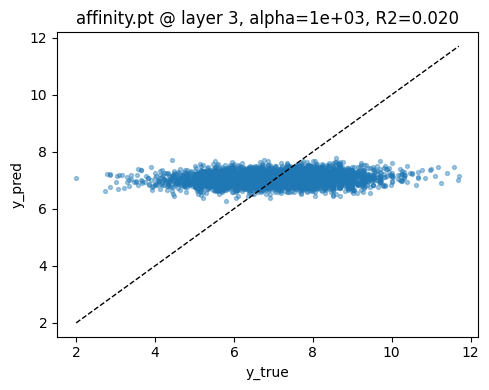

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
best_row = target_df.loc[target_df["r2"].idxmax()]
best_alpha = best_row["alpha"]
pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=best_alpha, random_state=RANDOM_STATE))])
X_train, X_test, y_train, y_test = target_split
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

ax.scatter(y_test, pred, s=8, alpha=0.4)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlabel("y_true")
ax.set_ylabel("y_pred")
ax.set_title(f"{TARGET_FILE} @ layer {LAYER}, alpha={best_alpha:.0e}, R2={best_row['r2']:.3f}")
plt.tight_layout()
plt.show()


## 5. Optional: run the real (`GridSearchCV` + stats + artifacts) probe for one layer

Only run this once the quick check above looks promising for a specific layer — it's
the same code path as the condor job (`run_probes` -> `run_cv_search`), just scoped to
one layer/target instead of the full 3-layer x 2-target sweep, so it's still much
faster than resubmitting `run_prob.sub`. Writes real artifacts under `output_dir`.

In [10]:
RUN_FULL_PROBE = True  # flip to True once you've picked a layer/target worth an official run

if RUN_FULL_PROBE:
    from prob.prob_orchestrate import linear_models

    X, y = load_target(TARGET_FILE, LAYER)
    runs = linear_models(prob_config, X, y, layer_num=LAYER, reuse_best_params=False)
    display(pd.DataFrame(runs))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits


,experiment,layer,r2,rmse,mae,fit_seconds,model__alpha
0,_ridge,3,0.019349,1.322457,1.082094,0.296902,10000.000
1,_lasso,3,0.019824,1.322137,1.080259,53.163256,0.001


## Running this on the cluster interactively

The batch job (`prob/cluster/run_prob.sub`) requests a GPU because the *extraction* step
needs one; the probing step here is pure CPU/sklearn on tensors that are already tens of
MB, so you don't need to resubmit that job to iterate. Two ways to get this notebook
running against the cluster's copy of the data:

- **If your local checkout's `data/probing/...` is already in sync with the cluster**
  (e.g. shared/mounted home, or you `scp`'d the small `.pt` files down), just run this
  notebook locally in the `kinodata3d` conda env -- that's what it was built and checked
  against.
- **If the data only lives on the cluster's storage**, start an interactive condor
  session against the same image so you can launch `jupyter lab` there and port-forward:
  `condor_submit -i` with a submit file mirroring `run_prob.sub` but without
  `request_GPUs` (drop it to `0`) and with a much smaller `request_memory`/`request_CPUs`
  (this notebook loads a handful of tensors, not the raw dataset) -- then run
  `jupyter lab --no-browser --port <port>` inside the container and forward that port
  over SSH.